# 03 — RK4 Integration and Physical Validation

Notebook 02 derived the Kerr geodesic acceleration symbolically. The resulting
algebra has now been moved into `src/kerr_schild.py` and JIT-compiled with
Numba.

This notebook asks a more important question than simply whether an orbit can
be plotted:

> **Does the numerical integrator reproduce a geodesic whose known physical
> invariants remain conserved?**

We begin with an exact circular timelike Schwarzschild orbit. This gives us a
strong test because we know what the radial coordinate should do.

We use geometrized units \(G=c=1\) and signature \((-+++)\).


In [3]:
from pathlib import Path
import sys
import time

import numpy as np
import matplotlib.pyplot as plt
from numba import njit
from scipy.integrate import solve_ivp


# ------------------------------------------------------------
# Make the project root importable when running from notebooks/
# ------------------------------------------------------------

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


from kerr_schild_geodesics.kerr_schild import (
    kerr_radius,
    metric_cov,
    geodesic_rhs,
    normalization,
    energy_lz,
    solve_ut_timelike,
)

print("Project root:", PROJECT_ROOT)
print("Imported Kerr-Schild numerical kernel successfully.")

Project root: /home/allanur/Desktop/kerr-schild-geodesics
Imported Kerr-Schild numerical kernel successfully.


## 1. Benchmark the generated numerical kernel

The first call includes Numba compilation. Later calls use native machine code.
This is the Python-only replacement for the old symbolic-to-Fortran workflow.


In [4]:
probe = np.array([0.0, 8.0, 1.5, 0.7, 1.1, 0.02, 0.12, 0.01])

start = time.perf_counter()
_ = geodesic_rhs(probe, 1.0, 0.5)
first_call = time.perf_counter() - start

n_eval = 100_000
start = time.perf_counter()
for _ in range(n_eval):
    geodesic_rhs(probe, 1.0, 0.5)
elapsed = time.perf_counter() - start

print(f"first call including JIT compilation: {first_call:.3f} s")
print(f"{n_eval:,} compiled RHS evaluations: {elapsed:.6f} s")
print(f"average compiled RHS evaluation: {1e6*elapsed/n_eval:.3f} microseconds")


first call including JIT compilation: 1.799 s
100,000 compiled RHS evaluations: 0.052976 s
average compiled RHS evaluation: 0.530 microseconds


## 2. Exact Schwarzschild circular-orbit test

Set \(a=0\). In the equatorial plane, a timelike circular Schwarzschild
geodesic at radius \(r_0>3M\) has

$$
u^t = \frac{1}{\sqrt{1-3M/r_0}},
$$

and

$$
u^\phi =
\frac{\sqrt{M/r_0^3}}{\sqrt{1-3M/r_0}}.
$$

At the initial Cartesian point \((x,y,z)=(r_0,0,0)\),

$$
u^x=0,\qquad
u^y=r_0u^\phi,\qquad
u^z=0.
$$

We choose \(r_0=10M\), comfortably outside the horizon and the ISCO.


In [5]:
M0 = 1.0
a0 = 0.0
r0 = 10.0

u_t_exact = 1.0 / np.sqrt(1.0 - 3.0*M0/r0)
u_phi = np.sqrt(M0/r0**3) / np.sqrt(1.0 - 3.0*M0/r0)

ux0 = 0.0
uy0 = r0*u_phi
uz0 = 0.0

u_t_from_metric = solve_ut_timelike(
    r0, 0.0, 0.0,
    ux0, uy0, uz0,
    M0, a0,
)

state0 = np.array([
    0.0,
    r0, 0.0, 0.0,
    u_t_exact, ux0, uy0, uz0,
])

print("analytic u^t       =", u_t_exact)
print("metric-solved u^t  =", u_t_from_metric)
print("difference          =", abs(u_t_exact - u_t_from_metric))
print("initial norm        =", normalization(state0, M0, a0))

E0, Lz0 = energy_lz(state0, M0, a0)
print("initial E           =", E0)
print("initial L_z         =", Lz0)


analytic u^t       = 1.1952286093343936
metric-solved u^t  = 1.1952286093343936
difference          = 0.0
initial norm        = -1.0
initial E           = 0.9561828874675149
initial L_z         = 3.779644730092272


For a timelike geodesic, the normalization should be

$$
g_{\mu\nu}u^\mu u^\nu=-1.
$$

The analytic and metric-solved values of \(u^t\) should also agree to numerical
precision.

## 3. Our own fourth-order Runge–Kutta integrator


In [6]:
@njit
def rk4_step(state, h, M, a):
    k1 = geodesic_rhs(state, M, a)
    k2 = geodesic_rhs(state + 0.5*h*k1, M, a)
    k3 = geodesic_rhs(state + 0.5*h*k2, M, a)
    k4 = geodesic_rhs(state + h*k3, M, a)

    return state + (h/6.0)*(k1 + 2.0*k2 + 2.0*k3 + k4)


@njit
def integrate_rk4(state0, h, n_steps, M, a):
    trajectory = np.empty((n_steps + 1, 8), dtype=np.float64)
    trajectory[0] = state0

    state = state0.copy()

    for n in range(n_steps):
        state = rk4_step(state, h, M, a)
        trajectory[n + 1] = state

    return trajectory


For the exact circular orbit, the proper-time orbital period is

$$
T_\tau = \frac{2\pi}{u^\phi}.
$$

We integrate for three full periods.


In [7]:
proper_period = 2.0*np.pi/u_phi
lambda_end = 3.0*proper_period

target_h = 0.02
n_steps = int(np.ceil(lambda_end/target_h))
h = lambda_end/n_steps

print("proper-time period =", proper_period)
print("integration span   =", lambda_end)
print("RK4 steps          =", n_steps)
print("actual h           =", h)

# First call also compiles the notebook-level RK4 loop.
start = time.perf_counter()
trajectory = integrate_rk4(state0, h, n_steps, M0, a0)
first_integration = time.perf_counter() - start

# Run once more to show the cost after compilation.
start = time.perf_counter()
trajectory = integrate_rk4(state0, h, n_steps, M0, a0)
compiled_integration = time.perf_counter() - start

print(f"first integration including RK4 JIT: {first_integration:.3f} s")
print(f"compiled integration only:           {compiled_integration:.6f} s")


proper-time period = 166.23745764132164
integration span   = 498.71237292396495
RK4 steps          = 24936
actual h           = 0.019999694133941488
first integration including RK4 JIT: 2.621 s
compiled integration only:           0.011264 s


## 4. Validate the Schwarzschild orbit

For this exact initial condition, the coordinate radius should remain
\(r=10M\). We also monitor three invariants:

$$
g_{\mu\nu}u^\mu u^\nu=-1,
$$

$$
E=-p_t,
$$

and

$$
L_z=p_\mu(\partial_\phi)^\mu.
$$


In [8]:
r_values = np.sqrt(
    trajectory[:, 1]**2
    + trajectory[:, 2]**2
    + trajectory[:, 3]**2
)

sample = trajectory[::10]

norm_values = np.array([
    normalization(state, M0, a0)
    for state in sample
])

EL_values = np.array([
    energy_lz(state, M0, a0)
    for state in sample
])

E_values = EL_values[:, 0]
Lz_values = EL_values[:, 1]

print("max |r-r0|          =", np.max(np.abs(r_values-r0)))
print("max |norm+1|        =", np.max(np.abs(norm_values+1.0)))
print("max |E-E0|          =", np.max(np.abs(E_values-E_values[0])))
print("max |Lz-Lz0|        =", np.max(np.abs(Lz_values-Lz_values[0])))
print("final xyz           =", trajectory[-1, 1:4])


max |r-r0|          = 4.014566457044566e-13
max |norm+1|        = 2.375877272697835e-14
max |E-E0|          = 1.021405182655144e-14
max |Lz-Lz0|        = 1.4654943925052066e-14
final xyz           = [1.00000000e+01 2.23965985e-12 0.00000000e+00]


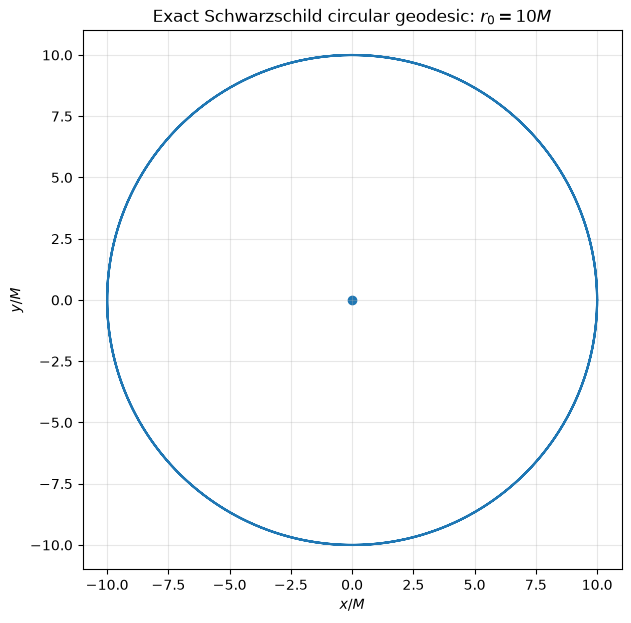

In [9]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(trajectory[:, 1], trajectory[:, 2])
ax.scatter([0.0], [0.0], marker="o")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$y/M$")
ax.set_title("Exact Schwarzschild circular geodesic: $r_0=10M$")
ax.grid(True, alpha=0.3)

plt.show()


## 5. Independent comparison with SciPy

Our RK4 implementation should agree with an independent high-order adaptive
solver.

We use `solve_ivp` with the `DOP853` method and stringent tolerances.


In [10]:
def rhs_scipy(lam, state):
    return geodesic_rhs(state, M0, a0)


start = time.perf_counter()

sol = solve_ivp(
    rhs_scipy,
    (0.0, lambda_end),
    state0,
    method="DOP853",
    rtol=1.0e-11,
    atol=1.0e-13,
)

scipy_time = time.perf_counter() - start

print("SciPy success:", sol.success)
print("SciPy RHS evaluations:", sol.nfev)
print("SciPy runtime:", scipy_time, "s")

final_difference = trajectory[-1] - sol.y[:, -1]

print("max absolute final-state difference =",
      np.max(np.abs(final_difference)))
print("final-state difference:")
print(final_difference)


SciPy success: True
SciPy RHS evaluations: 1274
SciPy runtime: 0.01276489000156289 s
max absolute final-state difference = 4.4724401959683746e-10
final-state difference:
[-4.47244020e-10  1.56571645e-10  3.53995173e-10  0.00000000e+00
 -7.37032657e-12 -1.18261714e-11 -5.31558131e-12  0.00000000e+00]


Agreement with an independent adaptive solver is an important
cross-check: it tells us that a visually plausible orbit is not merely an
artifact of our RK4 implementation.

## 6. First Kerr trajectory

Now set \(a=0.5M\).

For this first Kerr experiment we deliberately use nearly the same tangential
spatial initial data as in the Schwarzschild test. We then solve the timelike
normalization equation for \(u^t\).

This initial condition is **not claimed to be an exact circular Kerr orbit**.
Its purpose is to confirm that the full rotating-spacetime solver remains
stable and preserves the Kerr Killing invariants.

On the equatorial plane at \(y=z=0\), choosing

$$
x=\sqrt{r_0^2+a^2}
$$

makes the Kerr radial coordinate equal to the desired \(r_0\).


In [11]:
a_kerr = 0.5

x_kerr0 = np.sqrt(r0*r0 + a_kerr*a_kerr)

ut_kerr0 = solve_ut_timelike(
    x_kerr0, 0.0, 0.0,
    0.0, uy0, 0.0,
    M0, a_kerr,
)

state_kerr0 = np.array([
    0.0,
    x_kerr0, 0.0, 0.0,
    ut_kerr0, 0.0, uy0, 0.0,
])

print("initial Kerr r =", kerr_radius(x_kerr0, 0.0, 0.0, a_kerr))
print("initial Kerr u^t =", ut_kerr0)
print("initial Kerr norm =", normalization(state_kerr0, M0, a_kerr))
print("initial Kerr (E,Lz) =", energy_lz(state_kerr0, M0, a_kerr))


initial Kerr r = 10.0
initial Kerr u^t = 1.1905565193462848
initial Kerr norm = -0.9999999999999998
initial Kerr (E,Lz) = (0.9562201444913349, 3.667198149415269)


In [12]:
trajectory_kerr = integrate_rk4(
    state_kerr0,
    h,
    n_steps,
    M0,
    a_kerr,
)

sample_kerr = trajectory_kerr[::10]

r_kerr = np.array([
    kerr_radius(state[1], state[2], state[3], a_kerr)
    for state in trajectory_kerr
])

norm_kerr = np.array([
    normalization(state, M0, a_kerr)
    for state in sample_kerr
])

EL_kerr = np.array([
    energy_lz(state, M0, a_kerr)
    for state in sample_kerr
])

print("Kerr radial range =", r_kerr.min(), "to", r_kerr.max())
print("max |norm+1|      =", np.max(np.abs(norm_kerr + 1.0)))
print("max |E-E0|        =", np.max(np.abs(EL_kerr[:,0] - EL_kerr[0,0])))
print("max |Lz-Lz0|      =", np.max(np.abs(EL_kerr[:,1] - EL_kerr[0,1])))


Kerr radial range = 10.0 to 11.239655539276294
max |norm+1|      = 3.752553823233029e-14
max |E-E0|        = 1.7541523789077473e-14
max |Lz-Lz0|      = 5.995204332975845e-14


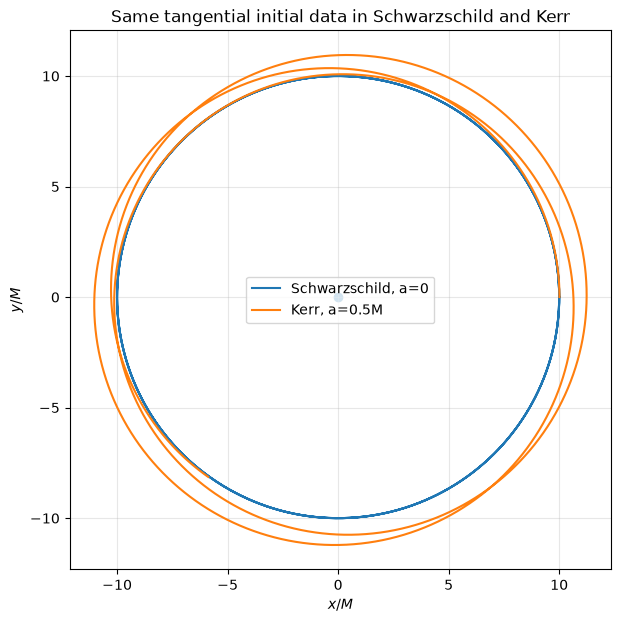

In [13]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.plot(
    trajectory[:, 1],
    trajectory[:, 2],
    label="Schwarzschild, a=0",
)

ax.plot(
    trajectory_kerr[:, 1],
    trajectory_kerr[:, 2],
    label="Kerr, a=0.5M",
)

ax.scatter([0.0], [0.0], marker="o")
ax.set_aspect("equal", adjustable="box")
ax.set_xlabel(r"$x/M$")
ax.set_ylabel(r"$y/M$")
ax.set_title("Same tangential initial data in Schwarzschild and Kerr")
ax.legend()
ax.grid(True, alpha=0.3)

plt.show()


## Interpretation and next step

If the Schwarzschild circular orbit remains at \(r=10M\) while normalization,
energy, and \(L_z\) remain conserved, then we have a very strong validation of
the reconstructed solver.

The Kerr example is intentionally **not** yet an exact circular-orbit test.
Notebook 04 will derive physically controlled Kerr initial conditions and
explore prograde/retrograde motion, frame dragging, photon trajectories, and
near-horizon behavior.

Before moving on, record the numerical values of:

- compiled RHS evaluation time,
- Schwarzschild radial drift,
- normalization drift,
- energy drift,
- angular-momentum drift,
- RK4 vs `solve_ivp` final-state difference,
- Kerr invariant drifts.

Those numbers will eventually become part of the repository's validation
documentation.
